# Badanie Efektywności Reprezentacji Ortogonalnej Sygnałów 1D

Autorzy:
- Grzegorz Cyba, 274859
- Jan Galewicz 272587

---

## **1. Wstęp**



wybrany temat

co chcemy zrobić aka założenia

krótki opis fouriera

zastosowania - do czego się używa

wszystko krótko bo dalej będzie rozwinięte

---

## **2. Generator danych**

W celu przeprowadzenia kompleksowej weryfikacji efektywności algorytmu kompresji widmowej opartego na transformacie Fouriera, niezbędne było przygotowanie zróżnicowanego materiału badawczego. Zaimplementowane środowisko pozwala na generowanie trzech klas sygnałów o odmiennych właściwościach w domenie czasu i częstotliwości. Pozwala to na rygorystyczne przetestowanie mechanizmu progowania współczynników pod kątem dokładności rekonstrukcji, zachowania energii oraz zmian entropii sygnału.

### **2.1. Budowa zbioru danych i symulacja zaszumienia pomiarowego**

Masowa synteza oraz agregacja struktur sygnałowych realizowana jest przez klasę zarządczą *DatasetCreator*. Narzędzie to automatyzuje proces budowy zbalansowanego datasetu testowego w dyskretnej dziedzinie czasu dla następujących parametrów:
- $t_0 = 0\text{ s}$ — czas początkowy przebiegu,
- $t_{end} = 500\text{ s}$ — czas końcowy przebiegu,
- $dt = 0.1\text{ s}$ — krok czasowy (co daje wektor o długości 5000 próbek),
- $u(t) \in [1, 10]$ — zakres dopuszczalnych wartości (amplitud).

**Powtarzalność i determinizm widma:**

W celu zapewnienia pełnej replikowalności eksperymentów, klasa wykorzystuje obiektowy generator liczb pseudolosowych `np.random.default_rng(seed)`. Przekazywanie tej samej instancji stanu losowego (`rng`) do klas sygnałowych gwarantuje, że przy identycznym ziarnie (seed) wygenerowane trajektorie czasowe oraz ich struktura spektralna (układ harmonicznych w widmie) będą identyczne przy każdym uruchomieniu.

**Separacja i kontekst badawczy zaszumienia**

Architektura generatora umożliwia ścisły podział na fazę syntezy danych czystych oraz eksperymentów szumowych poprzez tworzenie głębokich kopii bazy danych i nakładanie na nie zakłóceń Gaussowskich $(y_{noisy} = y_{clean} + N(0, \sigma))$ z zastosowaniem saturacji `np.clip` do barier fizycznych $[u_{min}, u_{max}]$. 

**Warto jednak podkreślić, że w dalszej części projektu oraz w zasadniczych testach algorytmów kompresji Fouriera skupiono się wyłącznie na danych niezaszumionych (czystych).** Pozwoliło to na rygorystyczną ocenę właściwości aproksymacyjnych samego transformatora widmowego, bez zniekształcania ocen jakości przez losowe artefakty szerokopasmowe.

Wygenerowane pakiety czystych danych (wektory $t$ oraz $y$) są ostatecznie kapsułkowane w ustrukturyzowanych obiektach klasy `SignalData` i mapowane w zbiorczym słowniku pod kluczami odpowiadającymi trzem odrębnym klasom sygnałów o zróżnicowanej naturze spektralnej: 

* **sygnałom skokowym (APRBS)**, 
* **wieloczęstotliwościowym (Multisine)**, 
* **stochastycznym (Filtered Noise)**. 

Szczegółowa charakterystyka matematyczna oraz spektralna każdej z tych trzech klas została zaprezentowana w kolejnym podrozdziale (pkt 2.2).

### **2.2 Klasy sygnałów**

Każda z zaimplementowanych klas sygnału reprezentuje inny typ struktury spektralnej, co pozwala na ocenę uniwersalności projektowanego kodeka.


#### ***2.2.1. Sygnał APRBS (Amplitude Pseudo-Random Binary Sequence)***


Sygnał ten charakteryzuje się gwałtownymi, dyskretnymi zmianami amplitudy (skokami napięcia) utrzymywanymi przez losowy czas. Dla każdego pojedynczego przebiegu parametry czasowe są losowane stochastycznie z następujących zakresów:
- $h_{min} \in [50; 150]$ — zakres, z którego losowany jest minimalny czas trwania pojedynczego kroku,
- $h_{add} \in [100; 300]$ — przedział definiujący dodatkowy czas, który po zsumowaniu z $h_{min}$ określa maksymalny czas trwania kroku ($h_{max}$).

**Znaczenie w analizie kompresji:** Z punktu widzenia analizy Fouriera, ostre zbocza i nieskończony gradient zmian w dziedzinie czasu generują ciągłe, bardzo bogate spektrum częstotliwościowe o wolno wygasających harmonicznych. Jest to najtrudniejszy test dla algorytmu kompresji widmowej. Wycięcie wysokich częstotliwości (współczynników FFT) prowadzi do utraty ostrości krawędzi i generuje charakterystyczne oscylacje wokół punktów skoku po wykonaniu odwrotnej transformaty (tzw. efekt Gibbsa). Pozwala to zbadać, jak mocno ucinanie pasma zniekształca skokowe sygnały szybkozmienne.

Generowanie APRBS        :   0%|          | 0/10 [00:00<?, ?it/s]

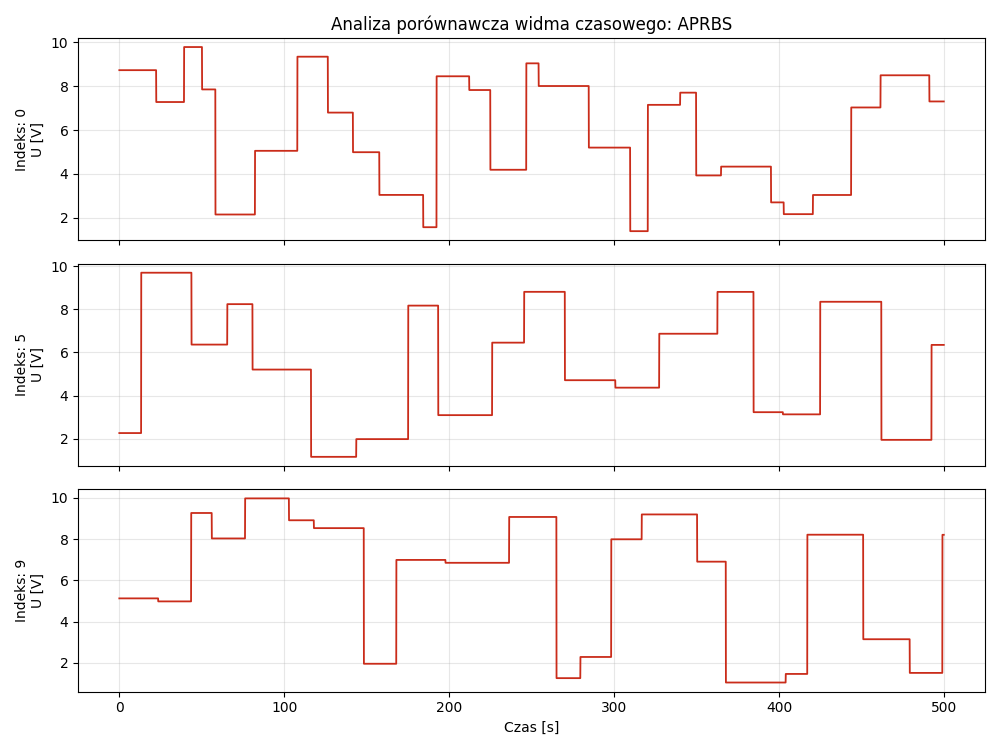

In [1]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=0, n_noise=0)

Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9])

# dataset_noisy = creator.create_noisy_dataset_copy()
# Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9], signals_noisy=dataset_noisy['aprbs'], noise_level=creator.noise_level)

#### ***2.2.2. Sygnał Multisine (Wieloczęstotliwościowy)***

Sygnał ten stanowi deterministyczną sumę składowych harmonicznych (sinusoid) o losowych fazach i częstotliwościach. Dla każdego przebiegu parametry konfiguracyjne losowane są z przedziałów:
- $n_f \in [5; 15]$ — zakres, z którego losowana jest liczba składowych sinusoidalnych,
- $f_{max} \in [0.005; 0.02]\text{ Hz}$ — zakres, z którego losowana jest maksymalna dopuszczalna częstotliwość pojedynczej sinusoidy.

**Znaczenie w analizie kompresji:** W dziedzinie częstotliwości sygnał ten charakteryzuje się ściśle dyskretnym spektrum prążkowym. Cała energia sygnału skupiona jest w dokładnie $n_f$ punktach widma, podczas gdy pozostała część pasma przyjmuje wartości zerowe. Dla kodeka fourierowskiego jest to sygnał idealny. Algorytm progowania powinien bezbłędnie wyizolować i zachować wyłącznie dominujące prążki częstotliwościowe, co pozwala na uzyskanie minimalnego błędu rekonstrukcji (MSE) i stabilnej entropii widmowej nawet przy bardzo niskim procencie zachowanych danych.

Generowanie MULTISINE    :   0%|          | 0/10 [00:00<?, ?it/s]

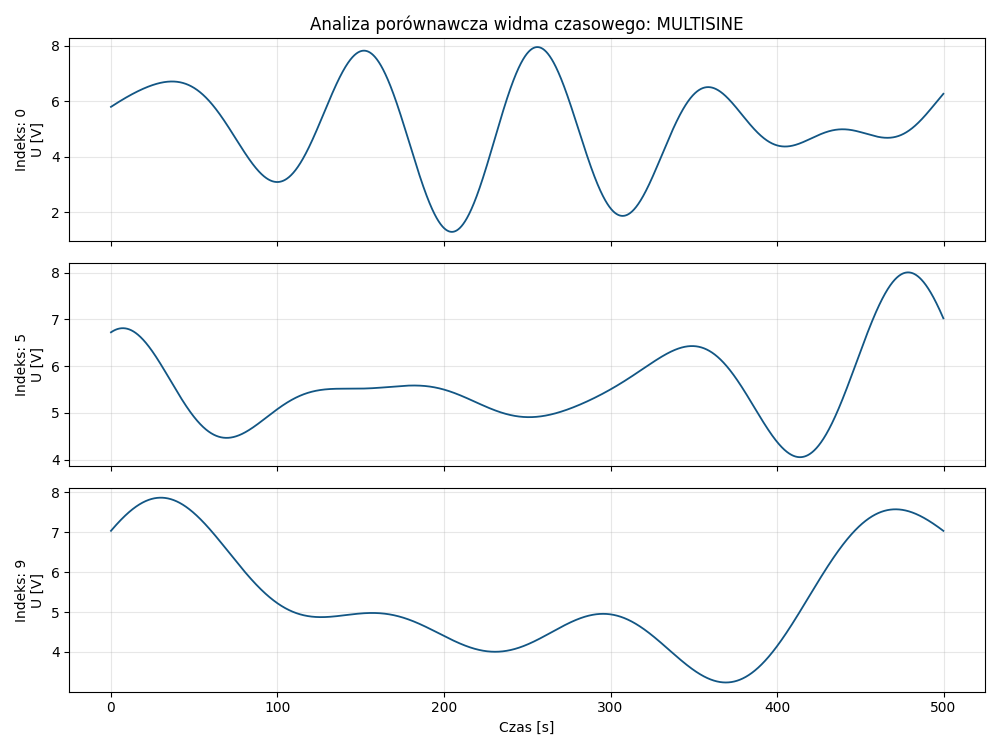

In [2]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.2, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=10, n_noise=0)

Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9])

# dataset_noisy = creator.create_noisy_dataset_copy()
# Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9], signals_noisy=dataset_noisy['multisine'], noise_level=creator.noise_level)

#### ***2.2.3. Przefiltrowany szum dolnoprzepustowy (Filtered Noise)***

Sygnał reprezentujący przebieg chaotyczny o kontrolowanym paśmie. Powstaje poprzez generację stochastycznego szumu białego o rozkładzie normalnym, który następnie poddawany jest cyfrowej filtracji dolnoprzepustowej pierwszego rzędu. Częstotliwość odcięcia filtra jest parametrem losowym:
- $cutoff \in [0.001; 0.01]\text{ Hz}$ — zakres losowania częstotliwości odcięcia.

**Znaczenie w analizie kompresji:** W dziedzinie częstotliwości sygnał ten posiada gęste, ciągłe pasmo szumowe ograniczone od góry filtrem wygładzającym. Brak pojedynczych, dominujących częstotliwości sprawia, że energia jest rozproszona. Pozwala to na zbadanie, jak algorytm kompresji radzi sobie z sygnałami stochastycznymi, gdzie ucinanie współczynników przekłada się bezpośrednio na liniową utratę losowej energii tła, co stanowi kluczowy punkt weryfikacji zmian entropii widmowej oraz dokładności odwzorowania szumów procesowych.

Generowanie NOISE        :   0%|          | 0/10 [00:00<?, ?it/s]

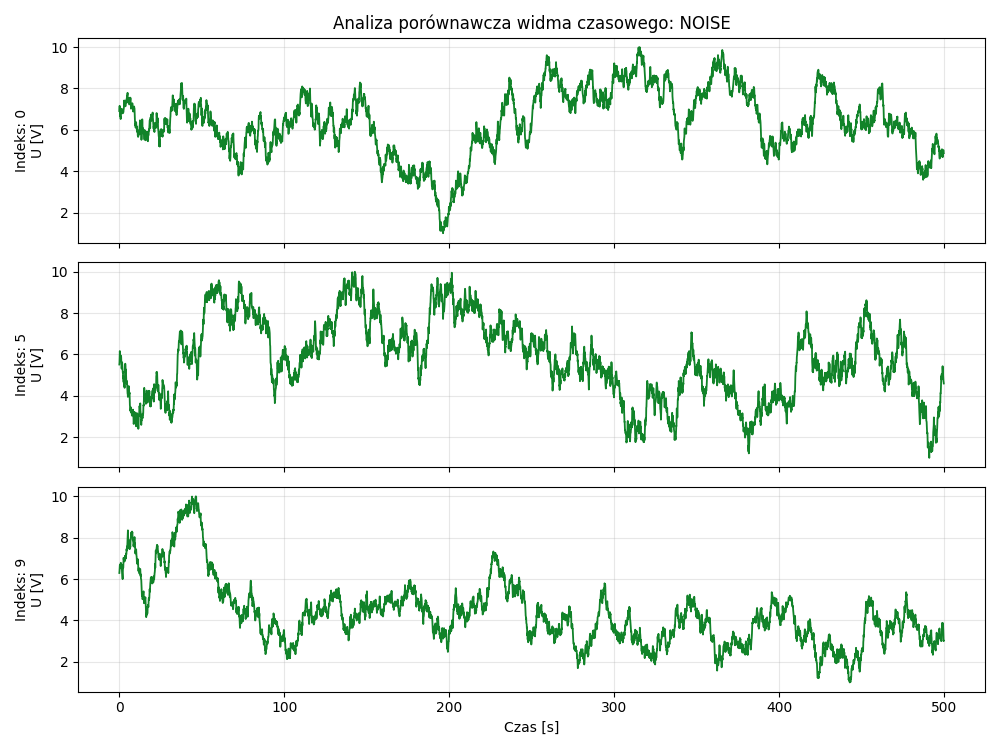

In [3]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.5, seed=42)
dataset = creator.create_dataset(n_aprbs=0, n_multisine=0, n_noise=10)

Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9])

# dataset_noisy = creator.create_noisy_dataset_copy()
# Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9], signals_noisy=dataset_noisy['noise'], noise_level=creator.noise_level)

---

## **3. Fourier**



podstawy teoretyczne (DFT)
- prosty
- odwrotny

opis kodu w markdown

kod do uruchomienia
- wykresy jak działa ucinanie (kompresja)
- mse
- przykładowe porównanie numpy vs własne

In [4]:
# # Wizualizacja porównania widm i rekonstrukcji
# Plotter.plot_fourier_comparison_widma(omega_vec, f_omega_vec, f_trimmed, K=results['k_threshold'], title=f"Widmo Fourier po selekcji wg {mode.upper()}")
# Plotter.plot_fourier_comparison(signal.t, signal.y, y_reconstructed, K=results['k_threshold'],title=f"Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}")

---

## **4. Strategie kompresji**

W tej sekcji zajmiemy się kompresją sygnału w dziedzinie częstotliwości. Cała sztuka polega na tym, żeby wyrzucić (wyzerować) te składowe widma, które niewiele wnoszą, i zostawić tylko te najważniejsze. Dzięki temu wektor częstotliwości staje się rzadki (ma dużo zer), co pozwala mocno "odchudzić" dane, zachowując kluczowe cechy sygnału.

Do wyznaczenia optymalnego punktu odcięcia współczynników przetestujemy dwa różne podejścia adaptacyjne:

1. **Analiza energii (Kryterium Energetyczne):** Podejście szybkie, działające w dziedzinie częstotliwości. Sortujemy prążki od najsilniejszego i na podstawie twierdzenia Parsevala zostawiamy tylko tyle współczynników, ile potrzeba, by zachować np. 99% całkowitej energii sygnału.

2. **Analiza dokładności (Kryterium Fidelity):** Podejście dokładniejsze, działające w dziedzinie czasu. Uruchamiamy szybki algorytm bisekcji (wyszukiwania binarnego), który krok po kroku sprawdza rzeczywisty błąd rekonstrukcji sygnału (MSE lub błąd maksymalny) i szuka minimalnego zestawu prążków, przy którym błąd nie przekracza zadanej tolerancji.

Zanim jednak przejdziemy do samych algorytmów, musimy zdefiniować matematyczne narzędzia, którymi będziemy mierzyli jakość i błędy rekonstrukcji sygnału po jego odtworzeniu.

### **4.1. Metryki oceny jakości rekonstrukcji**



Do oceny stopnia zniekształcenia sygnału po kompresji zaimplementowano klasę `SignalMetrics`. Wykorzystuje ona zestaw standardowych wskaźników jakościowych stosowanych w cyfrowym przetwarzaniu sygnałów (DSP):

* **Całkowita energia sygnału ($E$):** Suma kwadratów amplitudy próbek w dziedzinie czasu. Służy do weryfikacji bilansu energetycznego i wyznaczenia procentowej straty energii po kompresji.
$$E = \sum_{n=0}^{N-1} (y[n])^2$$

* **Błąd średniokwadratowy (MSE):** Mierzy średnią moc błędu rekonstrukcji. Jest bardzo czuły na większe odchyłki ze względu na podnoszenie różnic do kwadratu.
$$\text{MSE} = \frac{1}{N} \sum_{n=0}^{N-1} (y[n] - \hat{y}[n])^2$$

* **Pierwiastek błędu średniokwadratowego (RMSE):** Pierwiastek z MSE, dzięki czemu wynik ma tę samą jednostkę fizyczną co analizowany sygnał (np. Wolty, Ampery), co ułatwia bezpośrednią interpretację.
$$\text{RMSE} = \sqrt{\text{MSE}}$$

* **Maksymalny błąd bezwzględny ($\text{Max Error}$):** Wskazuje największą punktową, chwilową różnicę między oryginałem a rekonstrukcją. Pozwala sprawdzić, czy algorytm nie obciął kluczowych wartości szczytowych (pików).
$$\text{Max Error} = \max |y[n] - \hat{y}[n]|$$

* **Wskaźnik zniekształcenia PRD (*Percent Root-mean-square Difference*):** Kluczowa, znormalizowana metryka procentowa określająca globalny stopień zniekształcenia sygnału. Wartość 0% oznacza idealną rekonstrukcję. Jest niezależna od bezwzględnej skali amplitudy sygnału, co pozwala na porównywanie różnych przebiegów pomiarowych między sobą.
$$\text{PRD} = \sqrt{\frac{\sum_{n=0}^{N-1} (y[n] - \hat{y}[n])^2}{\sum_{n=0}^{N-1} (y[n])^2}} \cdot 100\%$$

Gdzie $y[n]$ to sygnał oryginalny, $\hat{y}[n]$ to sygnał zrekonstruowany, a $N$ to liczba próbek. W implementacji programowej przed obliczeniami nakładana jest operacja `np.real()`, która bezpiecznie odrzuca mikro-części urojone współczynników (rzędu $10^{-15}$), będące efektem ubocznym numerycznego zaokrąglania operacji zmiennoprzecinkowych w IDFT.

### **4.2. Algorytm oparty na analizie energii**

Kompresja sygnałów w dziedzinie częstotliwości z wykorzystaniem kryterium energetycznego opiera się na selektywnej eliminacji składowych spektralnych o relatywnie niskiej amplitudzie, których udział w całkowitym bilansie mocy sygnału jest pomijalny. Algorytm ten wykorzystuje fakt, że w przypadku większości sygnałów deterministycznych oraz sygnałów pomiarowych obciążonych szumem, informacja użyteczna skupiona jest w niewielkiej liczbie dominujących harmonicznych, podczas gdy składowe wysokoczęstotliwościowe oraz fluktuacje losowe niosą ze sobą minimalny ładunek energetyczny. Poprzez identyfikację i zachowanie wyłącznie kluczowych prążków spektralnych, możliwe jest uzyskanie wysokiego stopnia kompresji danych przy jednoczesnym zachowaniu pożądanego profilu sygnału pierwotnego.



#### ***4.2.1 Podstawa matematyczna i kryteria błędu***


Podstawą matematyczną tej metody jest twierdzenie Parsevala, które mówi, że całkowita energia sygnału obliczona w dziedzinie czasu jest równa całkowitej energii jego transformaty w dziedzinie częstotliwości:

$$\sum_{n=0}^{N-1} |y[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |Y[k]|^2$$

Gdzie:
* $y[n]$ — próbki sygnału w dziedzinie czasu,
* $Y[k]$ — zespolone współczynniki uzyskane z dyskretnej transformaty Fouriera (DFT),
* $N$ — całkowita liczba próbek sygnału (wymiar przestrzeni transformacji).

Ponieważ widmo sygnałów rzeczywistych cechuje się symetrią sprzężoną wokół częstotliwości Nyquista, algorytm operuje na modułach wszystkich współczynników $|Y[k]|$ w pełnym zakresie pasma $[0, f_s)$. Parametr $f_s$ oznacza częstotliwość próbkowania sygnału wejściowego (wyrażoną w hercach), która definiuje liczbę próbek rejestrowanych w ciągu sekundy. W procesie sortowania spektralnego symetryczne pary dominujących prążków są naturalnie pozycjonowane obok siebie. Pozwala to na bezbłędne zachowanie globalnego bilansu energetycznego według twierdzenia Parsevala, bez konieczności manualnej redukcji wymiarowości wektora częstotliwości czy odrębnego przetwarzania widma jednostronnego.



#### ***4.2.2. Przebieg procedury kompresji***



W celu numerycznej weryfikacji algorytmu, w strukturze skryptu testowego wydzielono trzy główne etapy przetwarzania sygnału częstotliwościowego. Poniższy opis szczegółowo definiuje operacje realizowane w każdym z kluczowych punktów programu:

1. **Wyznaczenie widma autorską metodą:** W tym kroku za pomocą statycznej metody klasy `DiscreteFourier.transform()` przetwarzane są wektory czasu (`signal.t`) oraz wartości sygnału (`signal.y`), a następnie wyznacza dyskretną transformatę Fouriera za pomocą metody `transform()`. Wynikiem działania są dwa wektory: `omega_vec` (zawierający fizyczne częstotliwości wyrażone w Hz) oraz `f_omega_vec` reprezentujący pełne, obustronne widmo zespolone o długości równej liczbie próbek wejściowych $N$.

2. **Analiza rozkładu energii:** Etap ten odpowiada za wyznaczenie optymalnej liczby współczynników spektralnych $K$ na podstawie zdefiniowanego przez użytkownika kryterium zachowania energii (`energy_threshold`). Wewnętrzna logika metody `analyze_energy_distribution` realizowana jest poprzez następujące kroki cząstkowe:
   * 2.1. **Obliczenie gęstości widmowej mocy:** Konwersja zespolonych współczynników $Y[k]$ na wartości rzeczywiste określające moc prążków poprzez obliczenie kwadratu ich modułu (`np.abs(coeffs)**2`).

   * 2.2. **Wyznaczenie energii całkowitej widma:** Obliczenie sumarycznej energii w dziedzinie częstotliwości z uwzględnieniem skalowania przez długość sygnału $N$. Wartość ta (`total_energy_freq`) stanowi bezpośredni odpowiednik energii czasowej sygnału pierwotnego.

   * 2.3. **Sortowanie spektralne współczynników:** Uszeregowanie wszystkich składowych mocy od wartości największej do najmniejszej. Krok ten pozwala na natychmiastową lokalizację dominujących harmonicznych sygnału.

   * 2.4. **Wyznaczenie profilu akumulacji energii:** Program tworzy wektor, który działa jak "licznik" zgromadzonej energii (`np.cumsum`). Idąc od najsilniejszego prążka do najsłabszego, algorytm dodaje energię kolejnych współczynników i sprawdza, jaki procent energii całkowitej już zebrał (wartość ta rośnie od 0 do 1, czyli do 100%).

   * 2.5. **Ekstrakcja indeksu granicznego $K$:** Wykorzystanie operacji logicznej i funkcji poszukiwania pierwszego indeksu spełniającego warunek brzegowy (`np.argmax(...) + 1`). Zwracana wartość `k_threshold` definiuje precyzyjnie, ile największych prążków widma należy zachować, aby nie przekroczyć narzuconego limitu strat.

3. **Kompresja (Przycięcie widma) i rekonstrukcja sygnału:** W ostatniej fazie wyznaczona wartość `k_threshold` przekazywana jest wraz z bazowym widmem do metody statycznej `DiscreteFourier.trim_spectrum()`. Funkcja ta wyznacza próg amplitudy dla $K$-tego największego współczynnika, a następnie tworzy maskę logiczną, która zachowuje nienaruszone prążki dominujące, a wszystkie pozostałe, mało istotne energetycznie składowe (szum, fluktuacje) nadpisuje wartością zero. Skompresowany w ten sposób wektor częstotliwości (`f_trimmed`) trafia do metody `DiscreteFourier.inverse_transform()`, gdzie za pomocą algorytmu IDFT następuje synteza czysto rzeczywistego sygnału wyjściowego `y_reconstructed`.

Efektem działania algorytmu jest drastyczne zredukowanie liczby niezerowych elementów w wektorze częstotliwości. Przekłada się to bezpośrednio na wysoki stopień kompresji danych przy jednoczesnym ścisłym, matematycznym kontrolowaniu dopuszczalnych strat informacji, co potwierdza końcowy bilans energetyczny sygnału skompresowanego (`e_time_reconstructed`).

#### ***4.2.3. Kod***

Generowanie APRBS        :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/1 [00:00<?, ?it/s]


[URUCHOMIENIE] Rozpoczęto analizę energetyczną dla typu: APRBS


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Dystrybucja Energii (Widmo)
[Konfiguracja] Zadany próg energii,99.90%
[Wynik selekcji] Wymagana liczba składowych (K),534
Energia oryginału (w dziedzinie częstotliwości),199496.0184
Energia oryginału (w dziedzinie czasu),199496.0184
Energia po rekonstrukcji (w dziedzinie czasu),199296.6017
Procentowa strata energii,0.10%
MSE,0.0398
RMSE,0.1995
MAX ERROR,3.0271


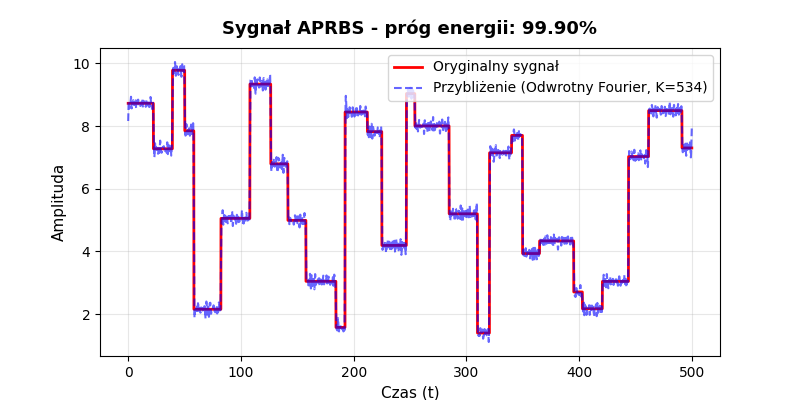


[URUCHOMIENIE] Rozpoczęto analizę energetyczną dla typu: MULTISINE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Dystrybucja Energii (Widmo)
[Konfiguracja] Zadany próg energii,99.90%
[Wynik selekcji] Wymagana liczba składowych (K),27
Energia oryginału (w dziedzinie częstotliwości),159777.0523
Energia oryginału (w dziedzinie czasu),159777.0523
Energia po rekonstrukcji (w dziedzinie czasu),159617.5161
Procentowa strata energii,0.10%
MSE,0.0319
RMSE,0.1786
MAX ERROR,1.6070


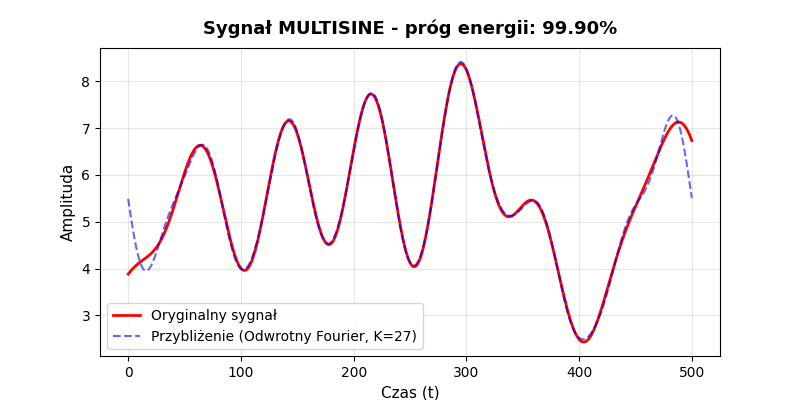


[URUCHOMIENIE] Rozpoczęto analizę energetyczną dla typu: NOISE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Dystrybucja Energii (Widmo)
[Konfiguracja] Zadany próg energii,99.90%
[Wynik selekcji] Wymagana liczba składowych (K),243
Energia oryginału (w dziedzinie częstotliwości),214293.1608
Energia oryginału (w dziedzinie czasu),214293.1608
Energia po rekonstrukcji (w dziedzinie czasu),214079.1335
Procentowa strata energii,0.10%
MSE,0.0428
RMSE,0.2069
MAX ERROR,1.5157


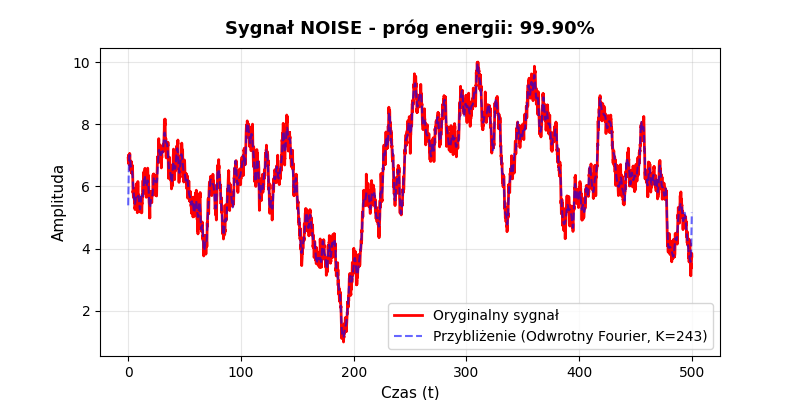


[SUKCES] Wszystkie sygnały zostały pomyślnie przetworzone pod kątem kryterium energetycznego!


In [4]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Fourier import DiscreteFourier
from EnergyAnalyzer import EnergyAnalyzer
from Plotter import Plotter
from tabulate import tabulate
from TableRenderer import ReportTableRenderer
from SignalMetrics import SignalMetrics  

# Inicjalizacja generatora i utworzenie zbioru danych
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
dataset = creator.create_dataset(n_aprbs=1, n_multisine=1, n_noise=1)

# Lista wszystkich rodzajów sygnałów do sekwencyjnej analizy energetycznej
signal_types = ['aprbs', 'multisine', 'noise']

# Globalny próg zachowania energii (99.9%)
energy_threshold = 0.999

# ==================================================================================
# GŁÓWNA PĘTLA PRZETWARZANIA ENERGETYCZNEGO
# ==================================================================================
for signal_type in signal_types:
    print(f"\n[URUCHOMIENIE] Rozpoczęto analizę energetyczną dla typu: {signal_type.upper()}")
    
    # Bezpieczne pobranie pierwszego sygnału z danej kategorii
    signal = dataset[signal_type][0]

    # ------------------------------------------------------------------------------
    # KROK 1: Wyznaczenie widma autorską metodą Fouriera
    omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

    # KROK 2: Analiza rozkładu energii - wyznaczenie progu K dla eth = 99.9%
    results_dsc = EnergyAnalyzer.analyze_energy_distribution(
        f_omega_vec, N=len(signal.y), threshold=energy_threshold
    )
    
    k_threshold = results_dsc['k_threshold']

    # KROK 3: Kompresja i rekonstrukcja sygnału na podstawie odciętego widma
    f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=k_threshold)
    y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)
    # ------------------------------------------------------------------------------

    # Automatyczne wyliczenie pełnego zestawu metryk wierności i energii
    metrics_results = SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed)

    # Konstrukcja struktury raportu tabelarycznego
    headers = ["Parametr / Wskaźnik jakości", "Wartość"]

    # Sekcja A: Założenia eksperymentu, selekcja K oraz energia tła częstotliwościowego
    rows = [
        ["[Konfiguracja] Tryb analizy błędu", "Dystrybucja Energii (Widmo)"],
        ["[Konfiguracja] Zadany próg energii", f"{energy_threshold * 100:.2f}%"],
        ["[Wynik selekcji] Wymagana liczba składowych (K)", f"{k_threshold}"],
        ["Energia oryginału (w dziedzinie częstotliwości)", f"{results_dsc['total_energy_freq']:.4f}"],
    ]

    # Sekcja B: Automatyczne dołączenie wszystkich metryk dynamicznych z formatowaniem %
    for key, val in metrics_results.items():
        if "strata" in key.lower():
            formatted_val = f"{val:.2f}%"
        elif "prd" in key.lower():
            formatted_val = f"{val:.2f}%"
        else:
            formatted_val = f"{val:.4f}" if isinstance(val, float) else str(val)
            
        rows.append([key, formatted_val])

    # Wyświetlenie zintegrowanej, nowoczesnej tabeli pastelowej w notebooku
    ReportTableRenderer.render(
        title=f"Kompletny raport wierności i energii sygnału {signal_type.upper()} (K = {k_threshold})",
        headers=headers,
        rows=rows
    )

    # Wizualizacja porównania widm i rekonstrukcji w dedykowanym oknie
    Plotter.plot_fourier_comparison(
        signal.t, 
        signal.y, 
        y_reconstructed, 
        K=k_threshold, 
        title=f"Sygnał {signal_type.upper()} - próg energii: {energy_threshold*100:.2f}%"
    )

print("\n[SUKCES] Wszystkie sygnały zostały pomyślnie przetworzone pod kątem kryterium energetycznego!")


### **4.3 Algorytm oparty na analizie dokładności (MSE / Max Error):**


Alternatywnym podejściem do kompresji spektralnej jest algorytm adaptacyjny sterowany kryterium wierności odwzorowania sygnału w dziedzinie czasu (ang. *Fidelity Criteria*). W przeciwieństwie do metody energetycznej, która analizuje strukturę widma w sposób globalny i statyczny, podejście wiernościowe bezpośrednio minimalizuje błędy powstałe w wyniku obcięcia bazy ortogonalnej, monitorując jakość rekonstrukcji w sposób iteracyjny.



#### ***4.3.1 Podstawa matematyczna i kryteria błędu***



Algorytm realizuje proces optymalizacji poszukujący minimalnej liczby składowych częstotliwościowych $K$, dla których błąd odwzorowania sygnału nie przekracza zadanego progu tolerancji $\epsilon$. W zależności od założeń aplikacyjnych, w strukturze klasy `FidelityAnalyzer` zaimplementowano dwa alternatywne tryby pracy (wskaźniki jakości):

1. **Błąd średniokwadratowy (MSE):** Kryterium to określa średnią energię błędu w całym horyzoncie czasowym. Pozwala na optymalizację globalnego kształtu sygnału, dopuszczając lokalne, szpilkowe odchyłki:
$$\text{MSE} = \frac{1}{N} \sum_{n=0}^{N-1} \left( y[n] - \hat{y}[n] \right)^2 \le \epsilon$$

2. **Błąd maksymalny ($\text{Max Error}$):** Kryterium o charakterze reżimowym, które bezwzględnie limituje największą chwilową odchyłkę amplitudy. Jest kluczowe w układach, gdzie lokalne zniekształcenie sygnału (np. ucięcie wartości szczytowej) mogłoby zafałszować interpretację fizyczną danych:
$$\text{Max Error} = \max_{0 \le n < N} |y[n] - \hat{y}[n]| \le \epsilon$$

Gdzie $y[n]$ oznacza sygnał oryginalny o długości $N$ próbek, natomiast $\hat{y}[n]$ to sygnał testowy, rekonstruowany dynamicznie na podstawie $k$ dominujących prążków widmowych.



#### ***4.3.2. Przebieg procedury kompresji***



Klasyczna, zachłanna implementacja tego podejścia wiąże się z drastycznym wzrostem złożoności obliczeniowej. Wyznaczenie błędu w dziedzinie czasu wymaga wykonania odwrotnej dyskretnej transformaty Fouriera (IDFT) w każdym kroku pętli. Przy złożoności pojedynczej transformaty równej $\mathcal{O}(N^2)$ i przeszukiwaniu liniowym, całkowita teoretyczna złożoność algorytmu adaptacyjnego wynosiłaby $\mathcal{O}(N^3)$, co przy długości sygnału $N = 5000$ próbek prowadzi do wykonania miliardów operacji zmiennoprzecinkowych i paraliżu wydajnościowego środowiska wykonawczego.

W celu zachowania autonomii kodu (nieaktywna flaga `use_numpy=False`) przy jednoczesnym zapewnieniu wysokiej wydajności numerycznej, w metodzie `FidelityAnalyzer.analyze_by_error` zastosowano **optymalizację poprzez prekalkulację bazy transformacji** oraz **logarytmiczne wyszukiwanie binarne**. 

W strukturze skryptu testowego wydzielono trzy główne etapy przetwarzania:

1. **Wyznaczenie widma pełnego metodą statyczną:** W pierwszym kroku za pomocą statycznej metody `DiscreteFourier.transform()` przetwarzane są wektory czasu (`signal.t`) oraz wartości sygnału (`signal.y`). Wynikiem działania funkcji są dwa wektory: `omega_vec` (fizyczne częstotliwości w Hz) oraz `f_omega_vec` (pełne, obustronne widmo zespolone o długości równej liczbie próbek wejściowych $N$). Wektor ten stanowi bazę wejściową dla analizatora wierności.

2. **Iteracyjna analiza wierności (Klasa `FidelityAnalyzer`):** Wyznaczony wektor współczynników o długości $N$ oraz sygnał źródłowy przekazywane są do metody statycznej `FidelityAnalyzer.analyze_by_error()`. Wewnętrzna struktura tej metody realizuje zoptymalizowaną pętlę wyszukiwania binarnego (bisekcji), wykonując następujące kroki funkcjonalne:
   * 2.1. **Sortowanie spektralne współczynników:** Algorytm oblicza moduły wszystkich zespolonych współczynników (`np.abs(coeffs)`) i porządkuje je malejąco za pomocą funkcji `np.argsort()[::-1]`. Wynikiem działania jest wektor indeksów `sorted_indices`, wskazujący składowe widma od najsilniejszej do najsłabszej.

   * 2.2. **Prekalkulacja macierzy bazowej IDFT:** Przed uruchomieniem właściwej pętli program jednorazowo generuje kompletną macierz wykładników zespolonych dla odwrotnej transformaty (IDFT) o wymiarach $N \times N$. Macierz ta jest od razu skalowana przez współczynnik $1/N$ i transponowana do postaci `W_inv_T`. Wyciągnięcie tej ciężkiej alokacji przed pętlę chroni procesor przed ciągłym narzutem pamięciowym.

   * 2.3. **Inicjalizacja wskaźników bisekcji:** Program definiuje początkowe punkty skrajne przedziału poszukiwań w dziedzinie częstotliwości (`low = 1`, `high = N`). Wykorzystanie bisekcji pozwala na drastyczne zredukowanie teoretycznej liczby kroków pętli ze złożoności liniowej $\mathcal{O}(N)$ do logarytmicznej $\mathcal{O}(\log_2 N)$. Przy głębokiej kompresji i rygorystycznych progach błędu (np. $\epsilon = 0.01$), zapobiega to wielokrotnemu powtarzaniu operacji macierzowych.

   * 2.4. **Dynamiczne przycinanie i rekonstrukcja sygnału:** W każdej iteracji wyznaczany jest punkt środkowy przedziału `mid = (low + high) // 2`. Program tworzy maskę `test_coeffs` o długości $N$, aktywując wyłącznie `mid` dominujących prążków i zerując resztę pasma częstotliwościowego. Następnie synteza sygnału w czasie (`y_hat`) realizowana jest poprzez szybki iloczyn macierzowy `np.dot(W_inv_T, test_coeffs).real`, co pozwala optymalnie wykorzystać sprzętowe właściwości pamięci podręcznej procesora.

   * 2.5. **Weryfikacja warunku stopu bisekcji:** W zależności od wybranego trybu (`mode='mse'` lub `mode='max_error'`), obliczany jest aktualny błąd odwzorowania sygnału `y_hat` względem `original_y`. Jeśli warunek dokładności jest spełniony (`current_error <= threshold`), algorytm tymczasowo zatrzaskuje zmienne wynikowe (`k_min = mid`, `reconstructed_y = y_hat`), po czym zawęża obszar poszukiwań do lewej połówki (`high = mid - 1`), sprawdzając, czy mniejsza liczba składowych również spełni kryterium. W przeciwnym wypadku, algorytm przenosi okno poszukiwań do prawej połówki (`low = mid + 1`). Pętla kończy pracę po zbiegnięciu się wskaźników, zwracając precyzyjnie wyznaczony próg kompresji.

3. **Kompresja (Przycięcie widma) i rekonstrukcja sygnału:** W ostatniej fazie wyznaczona adaptacyjnie wartość `results['k_threshold']` przekazywana jest wraz z bazowym widmem do metody statycznej `DiscreteFourier.trim_spectrum()`. Funkcja ta wyznacza próg amplitudy dla $K$-tego największego współczynnika, a następnie tworzy maskę logiczną, która zachowuje nienaruszone prążki dominujące, a wszystkie pozostałe składowe o niskiej istotności (szum, fluktuacje) nadpisuje wartością zero. Skompresowany w ten sposób wektor częstotliwości (`f_trimmed`) trafia do metody `DiscreteFourier.inverse_transform()`, gdzie za pomocą algorytmu IDFT następuje ostateczna synteza czysto rzeczywistego sygnału wyjściowego `y_reconstructed`.

Zastosowanie algorytmu przeszukiwania binarnego pozwoliło na redukcję teoretycznej złożonowści procedury adaptacyjnej z poziomu $\mathcal{O}(N^3)$ do klasy $\mathcal{O}(N^2 \log N)$. W połączeniu z niskopoziomową optymalizacją operacji BLAS, redukcja liczby niezbędnych operacji zmiennoprzecinkowych przełożyła się na radykalne skrócenie czasu obliczeń w testach empirycznych.


#### ***4.3.3 Kod (Analiza dokładności wg. MSE)***

Generowanie APRBS        :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/1 [00:00<?, ?it/s]


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: APRBS


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Średniokwadratowy (MSE)
[Konfiguracja] Zadany próg tolerancji,0.1000
[Wynik selekcji] Wymagana liczba składowych (K),210
Energia oryginału (w dziedzinie czasu),199496.0184
Energia po rekonstrukcji (w dziedzinie czasu),198996.8938
Procentowa strata energii,0.2502%
MSE,0.0994
RMSE,0.3153
MAX ERROR,3.2424
Wskaźnik zniekształcenia PRD,4.99%


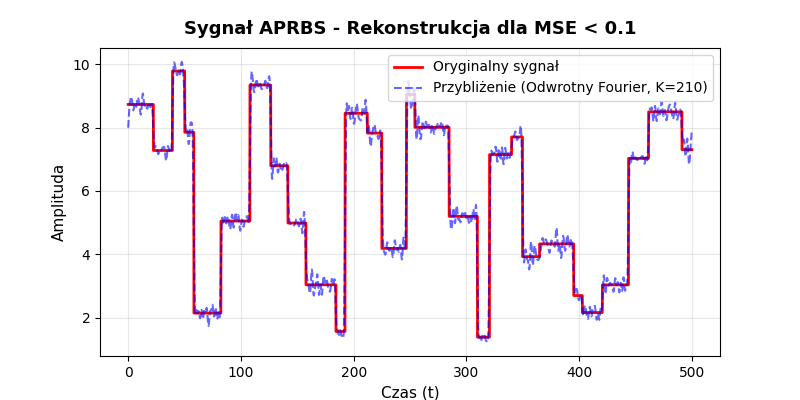


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: MULTISINE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Średniokwadratowy (MSE)
[Konfiguracja] Zadany próg tolerancji,0.1000
[Wynik selekcji] Wymagana liczba składowych (K),13
Energia oryginału (w dziedzinie czasu),159777.0523
Energia po rekonstrukcji (w dziedzinie czasu),159297.2194
Procentowa strata energii,0.3003%
MSE,0.0960
RMSE,0.3098
MAX ERROR,1.9198
Wskaźnik zniekształcenia PRD,5.48%


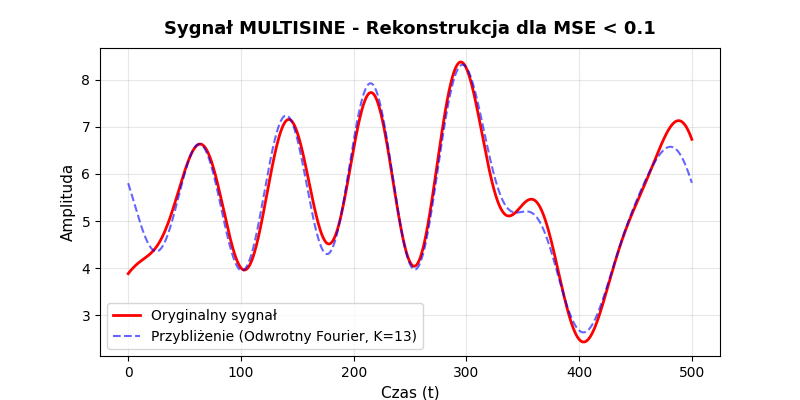


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: NOISE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Średniokwadratowy (MSE)
[Konfiguracja] Zadany próg tolerancji,0.1000
[Wynik selekcji] Wymagana liczba składowych (K),102
Energia oryginału (w dziedzinie czasu),214293.1608
Energia po rekonstrukcji (w dziedzinie czasu),213787.6057
Procentowa strata energii,0.2359%
MSE,0.0999
RMSE,0.3161
MAX ERROR,1.6173
Wskaźnik zniekształcenia PRD,4.83%


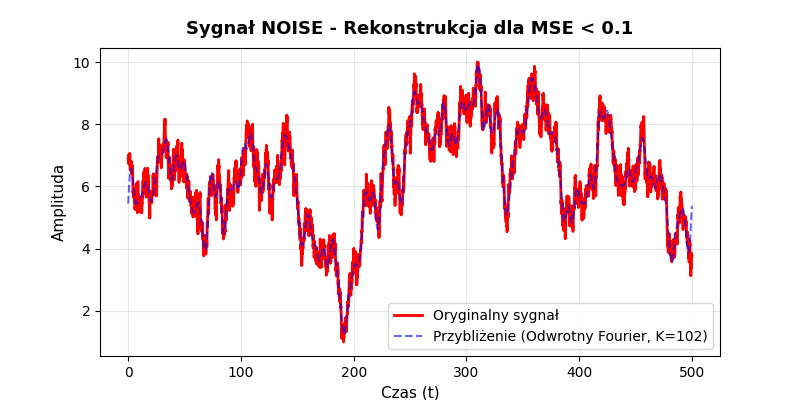


[SUKCES] Wszystkie typy sygnałów zostały pomyślnie przeanalizowane i zaraportowane!


In [5]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import DiscreteFourier
from FidelityAnalyzer import FidelityAnalyzer
from TableRenderer import ReportTableRenderer 
from SignalMetrics import SignalMetrics

# Inicjalizacja generatora i utworzenie zbioru danych
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
dataset = creator.create_dataset(n_aprbs=1, n_multisine=1, n_noise=1)

# Lista wszystkich rodzajów sygnałów do sekwencyjnej analizy
signal_types = ['aprbs', 'multisine', 'noise']

# Konfiguracja kryterium wierności (Fidelity)
max_allowed_diff = 0.1 
mode = 'mse'  # Opcje: 'mse' lub 'max_error'

# ==================================================================================
# GŁÓWNA PĘTLA PRZETWARZANIA
# ==================================================================================
for signal_type in signal_types:
    print(f"\n[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: {signal_type.upper()}")
    
    # Bezpieczne pobranie pierwszego sygnału z danej kategorii
    signal = dataset[signal_type][0]

    # ------------------------------------------------------------------------------
    # KROK 1: Wyznaczenie pełnego widma autorską metodą Fouriera
    omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

    # KROK 2: Analiza wierności - dynamiczne wyznaczenie progu K dla błędu < max_allowed_diff
    results = FidelityAnalyzer.analyze_by_error(
        signal.y, f_omega_vec, threshold=max_allowed_diff, mode=mode, use_numpy=False
    )
    
    k_threshold = results['k_threshold']

    # KROK 3: Kompresja i rekonstrukcja sygnału w dziedzinie czasu
    f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=k_threshold)
    y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)
    # ------------------------------------------------------------------------------

    # Ewaluacja metryk jakości rekonstrukcji sygnału
    metrics_results = SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed)

    # Konstrukcja struktury raportu tabelarycznego
    error_label = "Średniokwadratowy (MSE)" if mode == 'mse' else "Maksymalny (MAX ERROR)"
    headers = ["Parametr / Wskaźnik jakości", "Wartość"]

    # Sekcja A: Konfiguracja testu
    rows = [
        ["[Konfiguracja] Tryb analizy błędu", f"{error_label}"],
        ["[Konfiguracja] Zadany próg tolerancji", f"{max_allowed_diff:.4f}"],
        ["[Wynik selekcji] Wymagana liczba składowych (K)", f"{k_threshold}"],
    ]

    # Sekcja B: Automatyczne formatowanie metryk dynamicznych
    for key, val in metrics_results.items():
        if "strata" in key.lower():
            formatted_val = f"{val:.4f}%"
        elif "prd" in key.lower():
            formatted_val = f"{val:.2f}%"
        else:
            formatted_val = f"{val:.4f}" if isinstance(val, float) else str(val)
            
        rows.append([key, formatted_val])

    # Wyrenderowanie tabeli podsumowującej w notebooku
    ReportTableRenderer.render(
        title=f"Kompletny raport wierności i energii sygnału {signal_type.upper()} (K = {k_threshold})",
        headers=headers,
        rows=rows
    )

    # KROK 7: Wizualizacja rekonstrukcji w osobnym oknie wykresu
    Plotter.plot_fourier_comparison(
        signal.t, 
        signal.y, 
        y_reconstructed, 
        K=k_threshold,
        title=f"Sygnał {signal_type.upper()} - Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}"
    )
    
print("\n[SUKCES] Wszystkie typy sygnałów zostały pomyślnie przeanalizowane i zaraportowane!")

#### ***4.3.4 Kod (Analiza dokładności wg. Max Error)***

Generowanie APRBS        :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/1 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/1 [00:00<?, ?it/s]


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: APRBS


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Maksymalny (Max Error)
[Konfiguracja] Zadany próg tolerancji,1.0000
[Wynik selekcji] Wymagana liczba składowych (K),2464
Energia oryginału (w dziedzinie czasu),199496.0184
Energia po rekonstrukcji (w dziedzinie czasu),199470.4277
Procentowa strata energii,0.0128%
MSE,0.0051
RMSE,0.0715
MAX ERROR,0.9991
Wskaźnik zniekształcenia PRD,1.13%


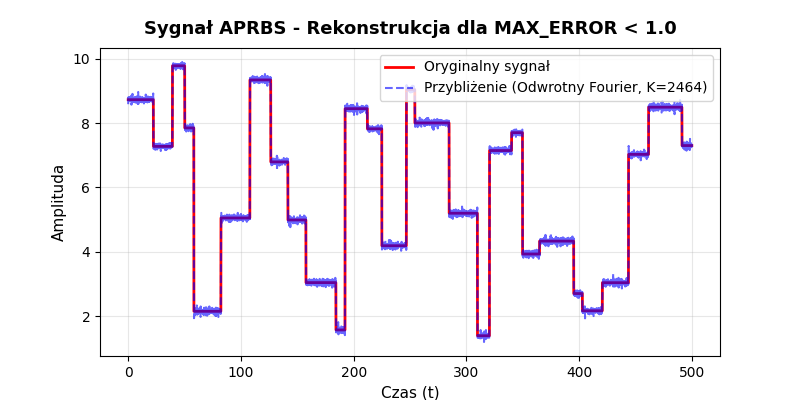


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: MULTISINE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Maksymalny (Max Error)
[Konfiguracja] Zadany próg tolerancji,1.0000
[Wynik selekcji] Wymagana liczba składowych (K),1495
Energia oryginału (w dziedzinie czasu),159777.0523
Energia po rekonstrukcji (w dziedzinie czasu),159774.5075
Procentowa strata energii,0.0016%
MSE,0.0005
RMSE,0.0226
MAX ERROR,0.9998
Wskaźnik zniekształcenia PRD,0.40%


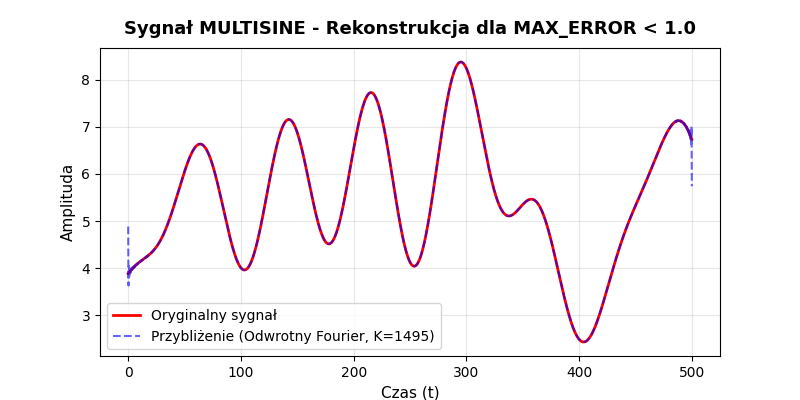


[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: NOISE


Parametr / Wskaźnik jakości,Wartość
[Konfiguracja] Tryb analizy błędu,Maksymalny (Max Error)
[Konfiguracja] Zadany próg tolerancji,1.0000
[Wynik selekcji] Wymagana liczba składowych (K),1390
Energia oryginału (w dziedzinie czasu),214293.1608
Energia po rekonstrukcji (w dziedzinie czasu),214262.2237
Procentowa strata energii,0.0144%
MSE,0.0062
RMSE,0.0786
MAX ERROR,0.9990
Wskaźnik zniekształcenia PRD,1.20%


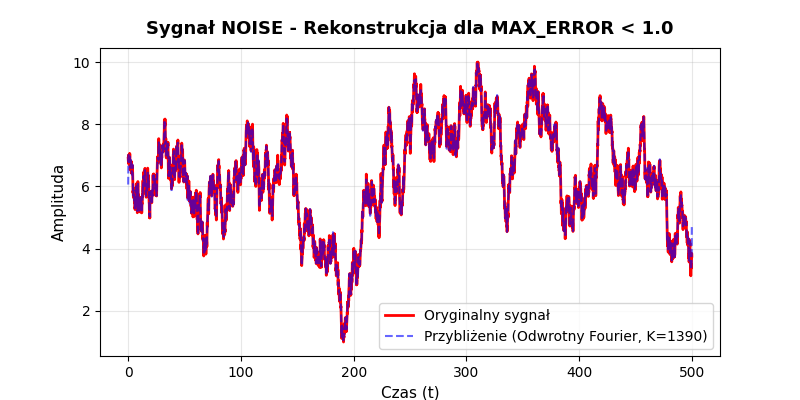


[SUKCES] Wszystkie typy sygnałów zostały pomyślnie przeanalizowane i zaraportowane!


In [6]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import DiscreteFourier
from FidelityAnalyzer import FidelityAnalyzer
from TableRenderer import ReportTableRenderer 
from SignalMetrics import SignalMetrics

# Inicjalizacja generatora i utworzenie zbioru danych
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
dataset = creator.create_dataset(n_aprbs=1, n_multisine=1, n_noise=1)

# Lista wszystkich rodzajów sygnałów do sekwencyjnej analizy
signal_types = ['aprbs', 'multisine', 'noise']

# Konfiguracja kryterium wierności (Fidelity)
max_allowed_diff = 1.0 
mode = 'max_error'  # Opcje: 'mse' lub 'max_error'

# ==================================================================================
# GŁÓWNA PĘTLA PRZETWARZANIA
# ==================================================================================
for signal_type in signal_types:
    print(f"\n[URUCHOMIENIE] Rozpoczęto analizę wierności dla typu: {signal_type.upper()}")
    
    # Bezpieczne pobranie pierwszego sygnału z danej kategorii
    signal = dataset[signal_type][0]

    # ------------------------------------------------------------------------------
    # KROK 1: Wyznaczenie pełnego widma autorską metodą Fouriera
    omega_vec, f_omega_vec = DiscreteFourier.transform(signal.t, signal.y)

    # KROK 2: Analiza wierności - dynamiczne wyznaczenie progu K dla błędu < max_allowed_diff
    results = FidelityAnalyzer.analyze_by_error(
        signal.y, f_omega_vec, threshold=max_allowed_diff, mode=mode, use_numpy=False
    )
    
    k_threshold = results['k_threshold']

    # KROK 3: Kompresja i rekonstrukcja sygnału w dziedzinie czasu
    f_trimmed = DiscreteFourier.trim_spectrum(f_omega_vec=f_omega_vec, k=k_threshold)
    y_reconstructed = DiscreteFourier.inverse_transform(f_trimmed)
    # ------------------------------------------------------------------------------

    # Ewaluacja metryk jakości rekonstrukcji sygnału
    metrics_results = SignalMetrics.evaluate_reconstruction(signal.y, y_reconstructed)

    # Konstrukcja struktury raportu tabelarycznego
    error_label = "Średniokwadratowy (MSE)" if mode == 'mse' else "Maksymalny (Max Error)"
    headers = ["Parametr / Wskaźnik jakości", "Wartość"]

    # Sekcja A: Konfiguracja testu
    rows = [
        ["[Konfiguracja] Tryb analizy błędu", f"{error_label}"],
        ["[Konfiguracja] Zadany próg tolerancji", f"{max_allowed_diff:.4f}"],
        ["[Wynik selekcji] Wymagana liczba składowych (K)", f"{k_threshold}"],
    ]

    # Sekcja B: Automatyczne formatowanie metryk dynamicznych
    for key, val in metrics_results.items():
        if "strata" in key.lower():
            formatted_val = f"{val:.4f}%"
        elif "prd" in key.lower():
            formatted_val = f"{val:.2f}%"
        else:
            formatted_val = f"{val:.4f}" if isinstance(val, float) else str(val)
            
        rows.append([key, formatted_val])

    # Wyrenderowanie tabeli podsumowującej w notebooku
    ReportTableRenderer.render(
        title=f"Kompletny raport wierności i energii sygnału {signal_type.upper()} (K = {k_threshold})",
        headers=headers,
        rows=rows
    )

    # Wizualizacja rekonstrukcji w osobnym oknie wykresu
    Plotter.plot_fourier_comparison(
        signal.t, 
        signal.y, 
        y_reconstructed, 
        K=k_threshold,
        title=f"Sygnał {signal_type.upper()} - Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}"
    )
    
print("\n[SUKCES] Wszystkie typy sygnałów zostały pomyślnie przeanalizowane i zaraportowane!")

---

## **5. Testy**


W tej sekcji zajmiemy się sprawdzeniem, jak nasze algorytmy kompresji oparte na transformacji Fouriera radzą sobie w praktyce przy masowym przetwarzaniu danych. Cały proces testowy został zaprojektowany tak, aby czarno na białym pokazać różnice pomiędzy wycinaniem widma za pomocą kryterium energetycznego a kryteriami dokładnościowymi (Fidelity).

Pokrótce omówimy tutaj konfigurację środowiska testowego, parametry przyjętych progów oraz to, jak zoptymalizowaliśmy skrypty pod kątem wydajności. Następnie przeanalizujemy, z jakimi problemami numerycznymi mierzą się algorytmy przy każdym z trzech typów sygnałów: skokowym (APRBS), sinusoidalnym (Multisine) oraz czystym szumie (Noise). Całość podsumujemy zbiorczymi tabelami z wynikami statystycznymi dla całej bazy danych.


### **5.1 Założenia testowe**



Eksperymenty numeryczne mają na celu masową i rygorystyczną ocenę efektywności kompresji spektralnej przy użyciu transformacji Fouriera. Zgodnie z wcześniejszymi założeniami projektowymi, zasadnicza faza testów masowych została przeprowadzona na **zbiorach danych czystych (niezaszumionych)** w celu precyzyjnej izolacji właściwości aproksymacyjnych samych kryteriów selekcji harmonicznych. 

**Główne zadanie skryptu testowego** 

Nadrzędnym celem algorytmu realizowanego w pętli masowej jest sekwencyjne wczytanie każdego sygnału z bazy danych, wyznaczenie jego pełnego widma częstotliwościowego, a następnie automatyczne wyliczenie optymalnego progu odcięcia (parametru $K$) niezależnie dla każdego z trzech kryteriów selekcji. Końcowym etapem jest kompresja widma, rekonstrukcja sygnału w dziedzinie czasu oraz automatyczna agregacja pełnego zestawu metryk jakościowych (MSE, RMSE, Max Error, PRD) w celu wyznaczenia wartości średnich i odchyleń standardowych dla całej populacji testowej.

**Metodologia wykonania i optymalizacja obliczeniowa**

Badania masowe zrealizowano dla bazy danych zawierającej po 1000 niezależnych sygnałów dla każdej z trzech głównych klas (APRBS, Multisine, Noise). **Wszystkie sygnały testowe w bazie zostały wygenerowane w przedziale amplitudy od 1 do 10, co stanowi bezpośredni punkt odniesienia dla interpretacji wartości bezwzględnych błędów rekonstrukcji (MSE, RMSE, Max Error).**

 W strukturze testów przyjęto następujące parametry konfiguracyjne dla poszczególnych strategii odcinania widma:

1. **Kryterium Energetyczne:** Progi zachowania skumulowanej energii widma ustawiono na poziomach: $99.0\%$, $99.9\%$ oraz $99.99\%$.
2. **Kryterium Dokładnościowe (Fidelity MSE):** Dopuszczalne progi błędu średniokwadratowego zdefiniowano jako: $0.01$, $0.1$ oraz $1.0$.
3. **Kryterium Dokładnościowe (Fidelity Max Error):** Maksymalne dopuszczalne odchylenie lokalne zdefiniowano na poziomach: $0.01$, $0.1$ oraz $1.0$.

Ze względu na specyfikę testów masowych (analiza łącznie kilku tysięcy sygnałów o długości 5000 próbek każdy, dla wielu konfiguracji progowych), kluczowym wyzwaniem okazała się złożoność obliczeniowa. Algorytmy zostały zaimplementowane i przetestowane w oparciu o dwa silniki matematyczne:
* **Autorska implementacja Fouriera (`DiscreteFourier`):** Służy jako referencyjny dowód poprawności matematycznej i logicznej całego aparatu kompresji. Została ona uruchomiona i zaprezentowana w ramach jednostkowego, szczegółowego profilowania algorytmów dla pojedynczych reprezentantów klasy sygnałowej (*APRBS*).

* **Silnik obliczeniowy NumPy (`np.fft`):** Ze względu na zoptymalizowane pod kątem sprzętowym funkcjonalności i nieporównywalnie wyższą szybkość wykonywania operacji, **całość zasadniczych testów masowych i agregacji statystyk w pętlach została zrealizowana przy użyciu silnika NumPy**. Pozwoliło to na skrócenie czasu przetwarzania zbiorów danych z wielu godzin do zaledwie kilkunastu sekund, przy zachowaniu tożsamej precyzji numerycznej.



### **5.2. Efektywność kompresji dla sygnałów APRBS:**


Sygnały typu APRBS (*Amplitude Pseudo-Random Binary Sequence*), jako przebiegi o charakterze skokowym, nieliniowym i nieciągłym, stanowią z natury najbardziej wymagający i problematyczny obiekt dla kompresji w dziedzinie częstotliwości. 

**Główne wyzwania:**

* **Nieskończone widmo a problem odcięcia:** Z punktu widzenia analizy spektralnej, idealnie pionowe zbocza sygnału skokowego generują nieskończone, wolno opadające pasmo częstotliwości. Wyzwanie kompresji polega tutaj na znalezieniu kompromisu pomiędzy redukcją danych a zachowaniem geometrii sygnału. 

* **Efekt Gibbsa jako bariera jakościowa:** Główne wyzwanie inżynierskie wiąże się z faktem, że odcięcie wyższych harmonicznych (niezbędnych do idealnej rekonstrukcji ostrych kantów) skutkuje powstawaniem tzw. efektu Gibbsa. Przejawia się on w postaci charakterystycznych oscylacji i "zafalowań" w rejonie występujących skoków amplitudy. Z tego powodu kryteria dokładnościowe (szczególnie maksymalny błąd lokalny) zmuszone są do drastycznego zwiększania liczby zachowywanych składowych ($K$), co bezpośrednio uderza w efektywność samej kompresji.

 
#### *Kod (Autorska implementacja Fourier'a)*


In [7]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester, EnergyTester, TesterUtils

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=2, n_multisine=2, n_noise=2)
signal_type = 'aprbs'

save = False # Ustaw na True, jeśli chcesz zapisać wyniki do plików CSV i Markdown
folder = "Custom_FFT" # Nazwa folderu do zapisu wyników dla autorskiego silnika FFT
use_custom_fft = True # Ustaw na False, aby użyć silnika NumPy, True dla autorskiego silnika FFT

# --- INICJALIZACJA TESTERÓW ---
energy_tester = EnergyTester(big_dataset)
fidelity_tester = FidelityTester(big_dataset)

# ==========================================================================
# ODPALENIE DLA SYGNAŁÓW APRBS - na silniku autorskim (use_custom_fft=True)
# ==========================================================================
# Krok 1: Zbieranie surowych danych
raw_energy_aprbs = energy_tester.run(signal_type, use_custom_fft=use_custom_fft)
raw_fidelity_mse_aprbs = fidelity_tester.run(signal_type, mode='mse', use_custom_fft=use_custom_fft)  
raw_fidelity_maxerror_aprbs = fidelity_tester.run(signal_type, mode='max_error', use_custom_fft=use_custom_fft) 

# Zapis danych pełnych (Niezagregowanych)
if save:
    TesterUtils.save_csv(raw_energy_aprbs, f"{folder}\\{signal_type}", f"raw_energy_custom_fft_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_mse_aprbs, f"{folder}\\{signal_type}", f"raw_fidelity_mse_custom_fft_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_maxerror_aprbs, f"{folder}\\{signal_type}", f"raw_fidelity_maxerror_custom_fft_{signal_type}.csv")

# Krok 2: Proces agregacji statystyk w Pandas (zwraca DataFrame)
summary_energy_aprbs = TesterUtils.aggregate(raw_energy_aprbs)
summary_fidelity_mse_aprbs = TesterUtils.aggregate(raw_fidelity_mse_aprbs)
summary_fidelity_maxerror_aprbs = TesterUtils.aggregate(raw_fidelity_maxerror_aprbs)

# Zapis danych zagregowanych
if save:
    TesterUtils.save_csv(summary_energy_aprbs, f"{folder}\\{signal_type}", f"summary_energy_custom_fft_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_mse_aprbs, f"{folder}\\{signal_type}", f"summary_fidelity_mse_custom_fft_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_maxerror_aprbs, f"{folder}\\{signal_type}", f"summary_fidelity_maxerror_custom_fft_{signal_type}.csv")

# Krok 3: Wyświetlenie gotowych tabel HTML
TesterUtils.render(signal_type, summary_energy_aprbs, save_md=save, save_name_suffix=f"summary_energy_custom_fft_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_mse_aprbs, save_md=save, save_name_suffix=f"summary_fidelity_mse_custom_fft_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_maxerror_aprbs, save_md=save, save_name_suffix=f"summary_fidelity_maxerror_custom_fft_{signal_type}", folder=f"{folder}\\{signal_type}")

Generowanie APRBS        :   0%|          | 0/2 [00:00<?, ?it/s]

Generowanie MULTISINE    :   0%|          | 0/2 [00:00<?, ?it/s]

Generowanie NOISE        :   0%|          | 0/2 [00:00<?, ?it/s]

Kryterium Energetyczne: APRBS                                            0%|          | 0/2 [00:00<?, ?it/s]

Kryterium Fidelity: APRBS - Silnik: Autorski - Metryka: MSE                   0%|          | 0/2 [00:00<?, ?it…

Kryterium Fidelity: APRBS - Silnik: Autorski - Metryka: MAX_ERROR             0%|          | 0/2 [00:00<?, ?it…

Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Energetyczne,Prog_Energii_99.0%,2,72.0,51,93,29.70,0.36084,0.5999,3.665,9.991%
Energetyczne,Prog_Energii_99.9%,2,713.0,534,892,253.14,0.03608,0.1897,2.836,3.159%
Energetyczne,Prog_Energii_99.99%,2,2957.0,2715,3199,342.24,0.00361,0.0600,0.654,1.000%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MSE),Tolerancja_0.01,2,1911.5,1723,2100,266.58,0.01000,0.1000,1.54,1.67%
Fidelity (MSE),Tolerancja_0.1,2,254.0,210,298,62.23,0.09965,0.3157,3.28,5.27%
Fidelity (MSE),Tolerancja_1.0,2,27.5,25,30,3.54,0.97472,0.9873,3.81,16.48%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MAX_ERROR),Tolerancja_0.01,2,4895.5,4893,4898,3.54,0.00000693,0.00263,0.00986,0.0440%
Fidelity (MAX_ERROR),Tolerancja_0.1,2,4290.0,4253,4327,52.33,0.00036601,0.01913,0.09957,0.3198%
Fidelity (MAX_ERROR),Tolerancja_1.0,2,2479.5,2464,2495,21.92,0.00604415,0.07751,0.99873,1.2998%


 
#### *Kod (Numpy'owa implementacja Fourier'a)*


In [8]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester, EnergyTester, TesterUtils

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=100, n_multisine=0, n_noise=0)
signal_type = 'aprbs'

save = False # Ustaw na True, jeśli chcesz zapisać wyniki do plików CSV i Markdown
folder = "Numpy_FFT" # Nazwa folderu do zapisu wyników dla silnika NumPy
use_custom_fft = False # Ustaw na False, aby użyć silnika NumPy, True dla autorskiego silnika FFT

# --- INICJALIZACJA TESTERÓW ---
energy_tester = EnergyTester(big_dataset)
fidelity_tester = FidelityTester(big_dataset)

# =========================================================================
# ODPALENIE DLA SYGNAŁÓW APRBS - na silniku NumPy
# =========================================================================
# Krok 1: Zbieranie surowych danych
raw_energy_aprbs = energy_tester.run(signal_type, use_custom_fft=use_custom_fft)
raw_fidelity_mse_aprbs = fidelity_tester.run(signal_type, mode='mse', use_custom_fft=use_custom_fft)  
raw_fidelity_maxerror_aprbs = fidelity_tester.run(signal_type, mode='max_error', use_custom_fft=use_custom_fft) 

# Zapis danych pełnych (Niezagregowanych)
if save:
    TesterUtils.save_csv(raw_energy_aprbs, folder=f"{folder}\\{signal_type}", filename=f"raw_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_mse_aprbs, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_maxerror_aprbs, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 2: Proces agregacji statystyk w Pandas (zwraca DataFrame)
summary_energy_aprbs = TesterUtils.aggregate(raw_energy_aprbs)
summary_fidelity_mse_aprbs = TesterUtils.aggregate(raw_fidelity_mse_aprbs)
summary_fidelity_maxerror_aprbs = TesterUtils.aggregate(raw_fidelity_maxerror_aprbs)

# Zapis danych zagregowanych
if save:
    TesterUtils.save_csv(summary_energy_aprbs, folder=f"{folder}\\{signal_type}", filename=f"summary_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_mse_aprbs, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_maxerror_aprbs, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 3: Wyświetlenie gotowych tabel HTML
TesterUtils.render(signal_type, summary_energy_aprbs, save_md=save, save_name_suffix=f"summary_energy_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_mse_aprbs, save_md=save, save_name_suffix=f"summary_fidelity_mse_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_maxerror_aprbs, save_md=save, save_name_suffix=f"summary_fidelity_maxerror_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")

Generowanie APRBS        :   0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Energetyczne: APRBS                                            0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Fidelity: APRBS - Silnik: NumPy - Metryka: MSE                      0%|          | 0/100 [00:00<?, ?…

Kryterium Fidelity: APRBS - Silnik: NumPy - Metryka: MAX_ERROR                0%|          | 0/100 [00:00<?, ?…

Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Energetyczne,Prog_Energii_99.0%,100,81.1,29,218,31.49,0.36587,0.6030,3.921,9.938%
Energetyczne,Prog_Energii_99.9%,100,765.9,285,1685,257.95,0.03702,0.1918,2.946,3.160%
Energetyczne,Prog_Energii_99.99%,100,2975.3,1968,3725,320.10,0.00370,0.0607,0.645,1.000%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MSE),Tolerancja_0.01,100,1986.6,976,2803,369.37,0.00999,0.1000,1.50,1.66%
Fidelity (MSE),Tolerancja_0.1,100,290.5,102,586,97.03,0.09973,0.3158,3.51,5.24%
Fidelity (MSE),Tolerancja_1.0,100,29.9,11,67,9.67,0.97716,0.9885,4.23,16.41%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MAX_ERROR),Tolerancja_0.01,100,4897.2,4839,4927,17.48,0.00000708,0.00265,0.00984,0.0440%
Fidelity (MAX_ERROR),Tolerancja_0.1,100,4239.1,4005,4423,83.53,0.00045075,0.02109,0.09953,0.3497%
Fidelity (MAX_ERROR),Tolerancja_1.0,100,2487.4,1980,2753,146.20,0.00649071,0.07979,0.99913,1.3221%



### **5.3. Efektywność kompresji dla sygnałów Multisine:**

Wieloczęstotliwościowe sygnały sinusoidalne reprezentują zupełnie odmienny charakter spektralny, będący idealnym środowiskiem dla ortogonalnej kompresji Fouriera. 

**Główne wyzwania:**

* **Problem rzadkości widma:** Podstawowym zagadnieniem badawczym w przypadku sygnałów *multisine* jest sprawdzenie, czy algorytmy selekcji potrafią bezbłędnie zidentyfikować deterministyczną strukturę harmonicznych. Ponieważ sygnał ten składa się fizycznie ze skończonej liczby czystych sinusoid, jego energia skupiona jest wyłącznie w konkretnych, odizolowanych prążkach częstotliwościowych.


#### *Kod (Numpy'owa implementacja Fourier'a)*

In [9]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester, EnergyTester, TesterUtils

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=0, n_multisine=100, n_noise=0)
signal_type = 'multisine'

save = False # Ustaw na True, jeśli chcesz zapisać wyniki do plików CSV i Markdown
folder = "Numpy_FFT" # Nazwa folderu do zapisu wyników dla silnika NumPy
use_custom_fft = False # Ustaw na False, aby użyć silnika NumPy, True dla autorskiego silnika FFT

# --- INICJALIZACJA TESTERÓW ---
energy_tester = EnergyTester(big_dataset)
fidelity_tester = FidelityTester(big_dataset)

# =========================================================================
# ODPALENIE DLA SYGNAŁÓW MULTISINE - na silniku NumPy
# =========================================================================
# Krok 1: Zbieranie surowych danych
raw_energy_multisine = energy_tester.run(signal_type, use_custom_fft=use_custom_fft)
raw_fidelity_mse_multisine = fidelity_tester.run(signal_type, mode='mse', use_custom_fft=use_custom_fft)  
raw_fidelity_maxerror_multisine = fidelity_tester.run(signal_type, mode='max_error', use_custom_fft=use_custom_fft) 

# Zapis danych pełnych (Niezagregowanych)
if save:
    TesterUtils.save_csv(raw_energy_multisine, folder=f"{folder}\\{signal_type}", filename=f"raw_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_mse_multisine, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_maxerror_multisine, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 2: Proces agregacji statystyk w Pandas (zwraca DataFrame)
summary_energy_multisine = TesterUtils.aggregate(raw_energy_multisine)
summary_fidelity_mse_multisine = TesterUtils.aggregate(raw_fidelity_mse_multisine)
summary_fidelity_maxerror_multisine = TesterUtils.aggregate(raw_fidelity_maxerror_multisine)

# Zapis danych zagregowanych
if save:
    TesterUtils.save_csv(summary_energy_multisine, folder=f"{folder}\\{signal_type}", filename=f"summary_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_mse_multisine, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_maxerror_multisine, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 3: Wyświetlenie gotowych tabel HTML
TesterUtils.render(signal_type, summary_energy_multisine, save_md=save, save_name_suffix=f"summary_energy_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_mse_multisine, save_md=save, save_name_suffix=f"summary_fidelity_mse_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_maxerror_multisine, save_md=save, save_name_suffix=f"summary_fidelity_maxerror_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")

Generowanie MULTISINE    :   0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Energetyczne: MULTISINE                                        0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Fidelity: MULTISINE - Silnik: NumPy - Metryka: MSE                  0%|          | 0/100 [00:00<?, ?…

Kryterium Fidelity: MULTISINE - Silnik: NumPy - Metryka: MAX_ERROR            0%|          | 0/100 [00:00<?, ?…

Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Energetyczne,Prog_Energii_99.0%,100,5.4,1,14,2.43,0.23704,0.4806,1.244,8.589%
Energetyczne,Prog_Energii_99.9%,100,14.6,5,64,8.33,0.02386,0.1517,0.870,2.710%
Energetyczne,Prog_Energii_99.99%,100,80.8,7,614,97.24,0.00281,0.0524,0.688,0.938%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MSE),Tolerancja_0.01,100,29.5,6,206,29.53,0.00874,0.0928,0.778,1.66%
Fidelity (MSE),Tolerancja_0.1,100,9.0,2,24,3.62,0.08027,0.2815,1.001,5.05%
Fidelity (MSE),Tolerancja_1.0,100,1.7,1,6,1.15,0.73005,0.8452,1.886,15.16%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MAX_ERROR),Tolerancja_0.01,100,4653.1,76,4978,890.88,0.00000124,0.00104,0.00994,0.0186%
Fidelity (MAX_ERROR),Tolerancja_0.1,100,3514.3,12,4778,1352.74,0.00003994,0.00466,0.09915,0.0840%
Fidelity (MAX_ERROR),Tolerancja_1.0,100,206.2,1,2779,523.85,0.09813997,0.26505,0.93191,4.7832%


### **5.4. Efektywność kompresji dla sygnałów Filtered Noise:**


Klasa sygnałów stochastycznych (szumowych) definiuje skrajny przypadek problemu kompresji spektralnej, w którym deterministyczne podejście bazujące na dominujących harmonicznych napotyka fundamentalne ograniczenia. 

**Główne wyzwania:**

* **Problem gęstej dystrybucji energii:** Sygnał szumowy charakteryzuje się widmem ciągłym, gęstym i równomiernie rozłożonym w całym pasmie analitycznym. W przeciwieństwie do poprzednich klas, nie występują tutaj żadne dominanty częstotliwościowe – każda składowa niesie zbliżony ładunek informacyjny i energetyczny.

* **Zjawisko filtracji zamiast kompresji:** Głównym problemem podlegającym badaniu jest zachowanie algorytmów w sytuacji, gdy redukcja danych (zmniejszanie parametru $K$) nie wynika z eliminacji redundancji, lecz działa jak klasyczny filtr dolnoprzepustowy. Usunięcie jakiejkolwiek części widma wiąże się w tym przypadku z bezpośrednim i nieodwracalnym wygładzaniem trajektorii czasowej. Wyzwaniem testowym jest tu wykazanie, jak wysokie wymagania stawiane są algorytmom kompresji Fouriera w obliczu procesów czysto losowych, gdzie zachowanie wysokiej wierności zmusza system do przetwarzania niemal pełnego widma częstotliwościowego.


#### *Kod (Numpy'owa implementacja Fourier'a)*

In [10]:
%matplotlib widget
from DatasetCreator import DatasetCreator
from Tester import FidelityTester, EnergyTester, TesterUtils

creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(1, 10), noise_level=0.0, seed=42)
big_dataset = creator.create_dataset(n_aprbs=0, n_multisine=0, n_noise=100)
signal_type = 'noise'

save = False # Ustaw na True, jeśli chcesz zapisać wyniki do plików CSV i Markdown
folder = "Numpy_FFT" # Nazwa folderu do zapisu wyników dla silnika NumPy
use_custom_fft = False # Ustaw na False, aby użyć silnika NumPy, True dla autorskiego silnika FFT

# --- INICJALIZACJA TESTERÓW ---
energy_tester = EnergyTester(big_dataset)
fidelity_tester = FidelityTester(big_dataset)

# =========================================================================
# ODPALENIE DLA SYGNAŁÓW NOISE - na silniku NumPy
# =========================================================================
# Krok 1: Zbieranie surowych danych
raw_energy_noise = energy_tester.run(signal_type, use_custom_fft=use_custom_fft)
raw_fidelity_mse_noise = fidelity_tester.run(signal_type, mode='mse', use_custom_fft=use_custom_fft)  
raw_fidelity_maxerror_noise = fidelity_tester.run(signal_type, mode='max_error', use_custom_fft=use_custom_fft) 

# Zapis danych pełnych (Niezagregowanych)
if save:
    TesterUtils.save_csv(raw_energy_noise, folder=f"{folder}\\{signal_type}", filename=f"raw_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_mse_noise, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(raw_fidelity_maxerror_noise, folder=f"{folder}\\{signal_type}", filename=f"raw_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 2: Proces agregacji statystyk w Pandas (zwraca DataFrame)
summary_energy_noise = TesterUtils.aggregate(raw_energy_noise)
summary_fidelity_mse_noise = TesterUtils.aggregate(raw_fidelity_mse_noise)
summary_fidelity_maxerror_noise = TesterUtils.aggregate(raw_fidelity_maxerror_noise)

# Zapis danych zagregowanych
if save:
    TesterUtils.save_csv(summary_energy_noise, folder=f"{folder}\\{signal_type}", filename=f"summary_energy_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_mse_noise, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_mse_numpy_{signal_type}.csv")
    TesterUtils.save_csv(summary_fidelity_maxerror_noise, folder=f"{folder}\\{signal_type}", filename=f"summary_fidelity_maxerror_numpy_{signal_type}.csv")

# Krok 3: Wyświetlenie gotowych tabel HTML
TesterUtils.render(signal_type, summary_energy_noise, save_md=save, save_name_suffix=f"summary_energy_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_mse_noise, save_md=save, save_name_suffix=f"summary_fidelity_mse_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")
TesterUtils.render(signal_type, summary_fidelity_maxerror_noise, save_md=save, save_name_suffix=f"summary_fidelity_maxerror_numpy_{signal_type}", folder=f"{folder}\\{signal_type}")

Generowanie NOISE        :   0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Energetyczne: NOISE                                            0%|          | 0/100 [00:00<?, ?it/s]

Kryterium Fidelity: NOISE - Silnik: NumPy - Metryka: MSE                      0%|          | 0/100 [00:00<?, ?…

Kryterium Fidelity: NOISE - Silnik: NumPy - Metryka: MAX_ERROR                0%|          | 0/100 [00:00<?, ?…

Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Energetyczne,Prog_Energii_99.0%,100,32.0,12,85,12.58,0.31907,0.5633,2.041,9.824%
Energetyczne,Prog_Energii_99.9%,100,315.8,109,734,118.53,0.03298,0.1811,0.959,3.157%
Energetyczne,Prog_Energii_99.99%,100,2048.0,1013,2994,412.72,0.00331,0.0573,0.349,1.000%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MSE),Tolerancja_0.01,100,950.8,388,1661,300.58,0.00999,0.1000,0.652,1.75%
Fidelity (MSE),Tolerancja_0.1,100,103.8,38,216,38.69,0.09940,0.3153,1.339,5.53%
Fidelity (MSE),Tolerancja_1.0,100,9.6,3,19,3.56,0.93844,0.9684,3.176,16.99%


Strategia,Konfiguracja,Liczba sygnałów,Średnie K,Min K,Max K,Std(K),Średnie MSE,Średnie RMSE,Średni Max Error,Średni PRD
Fidelity (MAX_ERROR),Tolerancja_0.01,100,4827.8,4719,4892,35.44,0.00000711,0.00266,0.00989,0.0467%
Fidelity (MAX_ERROR),Tolerancja_0.1,100,3534.2,2681,4542,289.44,0.00062316,0.02472,0.09961,0.4327%
Fidelity (MAX_ERROR),Tolerancja_1.0,100,409.4,50,3121,546.76,0.05493389,0.22135,0.99195,3.8753%


### **5.5. Wyniki**

#### ***Analiza sygnałów ARPBS***

Poniżej przedstawiono szczegółową interpretację wyników uzyskanych podczas masowych testów kompresji (1000 sygnałów) dla przebiegów skokowych typu APRBS.

##### Kryterium Energetyczne - Zbiorczy raport dla sygnałów: APRBS

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Prog_Energii_99.0%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>80.2</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>21</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>218</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>29.83</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.36876</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.6052</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.873</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>9.939%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Prog_Energii_99.9%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>758.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>204</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1685</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>255.02</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.03730</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1925</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2.924</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.160%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Prog_Energii_99.99%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>2968.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1631</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3746</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>329.11</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00373</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0609</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.654</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.000%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity Max Error) - Zbiorczy raport dla sygnałów: APRBS

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>4899.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4815</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4943</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>20.65</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00000706</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00265</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00985</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0438%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>4235.8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3839</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4476</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>84.88</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00045912</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.02126</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09955</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.3513%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>2484.6</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1705</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2856</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>167.22</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00653708</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.07996</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.99896</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.3205%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity MSE) - Zbiorczy raport dla sygnałów: APRBS

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>1983.8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>777</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2916</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>379.94</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00999</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.49</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.65%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>289.6</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>78</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>664</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>100.28</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09976</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.3158</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.49</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>5.22%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>30.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>10</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>76</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>10.14</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.97518</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.9875</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4.17</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>16.33%</td>
    </tr>
  </tbody>
</table>

##### Podsumowanie i rekomendacja dla APRBS



Przeprowadzone testy masowe jednoznacznie pokazują, że **sygnał o charakterze prostokątnym (skokowym) z natury bardzo słabo nadaje się do efektywnej kompresji przy użyciu bazy Fouriera**. Głównym trendem widocznym we wszystkich próbach jest bezpośredni konflikt pomiędzy redukcją danych a wiernością odwzorowania ostrych krawędzi sygnału. 

Kryterium błędu maksymalnego (`MAX_ERROR`) kompletnie kapituluje w tym środowisku, blokując kompresję (średnie $K$ w okolicach 2484–4899) przez swoją nadwrażliwość na oscylacje Gibbsa powstające przy pionowych zboczach. Z kolei **kryterium Energetyczne oraz Fidelity (MSE) można uznać za narzędzia równorzędne**, a ich realna użyteczność zależy wyłącznie od świadomie przyjętego progu. Jeśli inżynier zgodzi się na pewne zniekształcenia fali, oba te podejścia pozwalają na uzyskanie bardzo dobrego i zbliżonego stopnia kompresji. Na przykład dla progu energii $99.0\%$ otrzymujemy świetną redukcję danych do średniego $K \approx 80$, przy zniekształceniach $PRD \approx 9.94\%$. Zaostrzenie kryterium do $99.9\%$ drastycznie poprawia jakość ($PRD \approx 3.16\%$), ale wymaga już zachowania $K \approx 758$ składowych. Podobną elastyczność oferuje kryterium błędu średniokwadratowego, gdzie dla tolerancji $MSE = 0.1$ algorytm schodzi do $K \approx 290$ (przy $PRD \approx 5.22\%$). 

Ostatecznie wybór między nimi sprowadza się do tego, czy w danym projekcie łatwiej i wygodniej jest operować procentem zachowanej energii całego widma, czy dopuszczalną wartością błędu średniokwadratowego w dziedzinie czasu.

#### ***Analiza sygnałów Multisine***

##### Kryterium Energetyczne - Zbiorczy raport dla sygnałów: MULTISINE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Prog_Energii_99.0%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>5.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>16</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2.33</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.22996</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.4734</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.241</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>8.460%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Prog_Energii_99.9%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>15.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>115</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>10.14</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.02320</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1490</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.855</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2.662%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Prog_Energii_99.99%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>83.8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>7</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1087</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>115.26</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00284</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0528</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.688</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.944%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity Max Error) - Zbiorczy raport dla sygnałów: MULTISINE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>4724.9</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>76</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4984</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>635.54</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00000123</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00102</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00994</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0183%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>3424.4</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>7</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4832</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1436.08</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00003306</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00438</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09949</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0785%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>242.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3319</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>586.59</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.10533416</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.27477</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.92909</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4.9480%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity MSE) - Zbiorczy raport dla sygnałów: MULTISINE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>30.7</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>358</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>34.86</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00871</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0927</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.774</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.66%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>9.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>39</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.65</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.07980</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.2806</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.999</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>5.04%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>1.8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>8</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.13</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.71973</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.8389</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.916</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>15.04%</td>
    </tr>
  </tbody>
</table>

##### Podsumowanie i rekomendacja dla Multisine


Testy masowe jednoznacznie potwierdzają, że **sygnały wieloczęstotliwościowe (Multisine) są świetnym obiektem do kompresji metodą Fouriera**, ale ich rzeczywiste parametry generacji ujawniają fundamentalne ograniczenia dyskretnej transformaty. Sygnały te składają się z losowej liczby komponentów sinusoidalnych ($n_f \in [5; 15]$) o losowych częstotliwościach.

Głównym trendem i wnioskiem inżynierskim jest to, że **kryterium Energetyczne oraz Fidelity (MSE) są narzędziami w pełni równorzędnymi**, dającymi zbliżoną, bardzo wysoką wydajność. Wybór między nimi zależy tylko od preferencji (sterowanie procentem energii widma, gdzie próg $99.9\%$ daje $K \approx 15$, czy wartością błędu w dziedzinie czasu, gdzie $MSE = 0.01$ daje $K \approx 31$).

Kluczowym zjawiskiem zaobserwowanym w badaniach jest zachowanie algorytmów przy bardzo rygorystycznych progach (np. energia $99.99\%$ lub `MAX_ERROR` $\le 0.1$). Ponieważ częstotliwości sygnału są losowane w sposób ciągły, **nie trafiają one idealnie w sztywną, dyskretną siatkę częstotliwościową transformaty Fouriera. Powoduje to tzw. wyciek widma (spectral leakage)** – energia pojedynczej sinusoidy rozlewa się na sąsiednie prążki. Z tego powodu:
1. Przy skrajnie wysokich wymaganiach energetycznych algorytm zmuszony jest dobierać dodatkowe, sztuczne składowe bocznego tła (stąd wzrost średniego $K$ do $83.8$, mimo maksymalnie $15$ fizycznych sinusoid).
2. Wyciek widma generuje niedopasowanie okresowości na brzegach okna analizy, co wywołuje silne oscylacje na początkach i końcach zrekonstruowanego przebiegu. To właśnie te zniekształcenia brzegowe generują wysoki błąd lokalny i kompletnie dyskwalifikują kryterium **MAX_ERROR** ($K > 3400$ dla tolerancji $0.1$).

**Rekomendacja projektowa:** Aby zniwelować ten problem i pozwolić algorytmowi na dokładniejsze "wstrzelenie się" w rzeczywiste częstotliwości generatora, konieczne byłoby zagęszczenie siatki spektralnej, co w praktyce wymagałoby zwiększenia częstotliwości próbkowania.

#### ***Analiza sygnałów Filtered Noise***

##### Kryterium Energetyczne - Zbiorczy raport dla sygnałów: NOISE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Prog_Energii_99.0%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>31.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>7</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>88</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>13.20</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.32111</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.5649</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2.055</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>9.824%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Prog_Energii_99.9%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>310.4</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>49</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>824</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>126.85</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.03319</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1816</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.980</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.157%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Energetyczne</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Prog_Energii_99.99%</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>2015.2</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>589</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3121</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>451.14</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00333</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0575</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.374</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.000%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity Max Error) - Zbiorczy raport dla sygnałów: NOISE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>4826.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4627</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4913</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>39.68</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00000700</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00264</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00989</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.0462%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>3540.3</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>2303</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>4542</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>283.15</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00060858</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.02438</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09962</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.4267%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MAX_ERROR)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>444.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>29</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3121</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>514.75</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.04999844</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.20870</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.99308</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.6533%</td>
    </tr>
  </tbody>
</table>

##### Kryterium Dokładnościowe (Fidelity MSE) - Zbiorczy raport dla sygnałów: NOISE

<table style='border-collapse: collapse; width: 100%; border: 1px solid #cbd5e1; border-radius: 6px; overflow: hidden;'>
  <thead>
    <tr>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Strategia</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Konfiguracja</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Liczba sygnałów</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Min K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Max K</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Std(K)</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie MSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średnie RMSE</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni Max Error</th>
      <th style='background-color: #e0f2fe; color: #0369a1; padding: 12px 14px; text-align: left; font-weight: 700; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; border-bottom: 2px solid #bae6fd;'>Średni PRD</th>
    </tr>
  </thead>
  <tbody>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>934.5</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>250</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1891</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>313.69</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.00999</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.681</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.75%</td>
    </tr>
    <tr style='background-color: #ffffff;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_0.1</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>101.9</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>22</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>242</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>40.01</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.09930</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.3151</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>1.355</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>5.52%</td>
    </tr>
    <tr style='background-color: #f8fafc;'>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 600; color: #0f172a;'>Fidelity (MSE)</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-family: 'SFMono-Regular', Consolas, 'Liberation Mono', Menlo, monospace; font-size: 12px; color: #334155; font-weight: 600;'>Tolerancja_1.0</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; color: #64748b; font-weight: 500;'>1000</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px; font-weight: 700; color: #0f172a; background-color: #e6f4ea;'>9.3</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>24</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.53</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.93660</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>0.9673</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>3.179</td>
      <td style='padding: 11px 14px; border-bottom: 1px solid #e2e8f0; color: #1e293b; font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Helvetica, Arial, sans-serif; font-size: 13px;'>16.93%</td>
    </tr>
  </tbody>
</table>

##### Podsumowanie i rekomendacja dla Filtered Noise


Masowe testy dla sygnałów zniekształconych szumem (Filtered Noise) reprezentują najtrudniejszy przypadek testowy. Ponieważ szum z natury charakteryzuje się ciągłym, gęstym widmem częstotliwościowym (brak wyraźnych, pojedynczych prążków), algorytmy kompresji oparte na bazie Fouriera napotykają tu na największy opór matematyczny.

Głównym trendem dla tej klasy sygnałów jest ponowna **pełna równorzędność kryterium Energetycznego oraz Fidelity (MSE)**. Oba podejścia bardzo ładnie i przewidywalnie skalują się w zależności od potrzeb użytkownika. Wybór między nimi to ponownie kwestia inżynierskiej wygody:
1. W **kryterium Energetycznym** płynnie sterujemy zachowaniem mocy widma – od silnej kompresji przy progu $99.0\%$ ($K \approx 31.5$, $PRD \approx 9.82\%$) do wysokiej dokładności przy progu $99.99\%$, gdzie jednak algorytm musi zachować aż $K \approx 2015$ składowych, ale uzyskuje  $PRD \approx 1.00\%$.
2. W **kryterium Fidelity (MSE)** uzyskujemy analogiczny, stabilny rozrzut – od ultra-kompresji dla tolerancji $1.0$ ($K \approx 9.3$, $PRD \approx 16.93\%$) do precyzyjnego odwzorowania dla tolerancji $0.01$ ($K \approx 934.5$, $PRD \approx 1.75\%$).

Kryterium błędu maksymalnego (**MAX_ERROR**) po raz kolejny okazuje się **najmniej efektywne i kompletnie kapituluje przy rygorystycznych progach** ($0.01$ oraz $0.1$), blokując kompresję na poziomie średniego $K$ rzędu $3540 - 4826$. Wynika to bezpośrednio z faktu, że losowy charakter szumu generuje ciągłe, nieprzewidywalne fluktuacje amplitudy na przestrzeni całego okna czasowego, a w szczególności na jego brzegach (początek i koniec przebiegu), gdzie transformata Fouriera cierpi na brak okresowości sygnału. Próba zredukowania błędu maksymalnego w tych krytycznych, pojedynczych punktach zmusza algorytm do zapamiętywania niemal całego pasma częstotliwościowego, co całkowicie niweczy sens stosowania kompresji spektralnej dla wyśrubowanych tolerancji lokalnych.

---

## **6. Kompresja Audio**

co to wav

zastosowanie

własny koder i dekoder

kod do uruchomienia

wykresy i tabele

Analiza

---

## 7. Podsumowanie